# Visual diagnostics

A plot is useful when it answers a question about the data or the model. This notebook uses three common diagnostics: a pair plot for feature relationships, a normalized confusion matrix for classification errors, and a residual plot for regression.


## Feature relationships

The pair plot displays the distributions and pairwise relationships of the features before fitting the classifier. It can reveal different scales, correlations, overlap between classes, and possible outliers. It does not replace a held-out evaluation.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification, make_regression
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

sns.set_theme(style='whitegrid', context='notebook')
rng = np.random.default_rng(12)

## Confusion matrix

The confusion matrix is normalized by the true class. Each row therefore shows how observations from that class were classified. This makes class-specific errors visible even when the class counts are unequal.


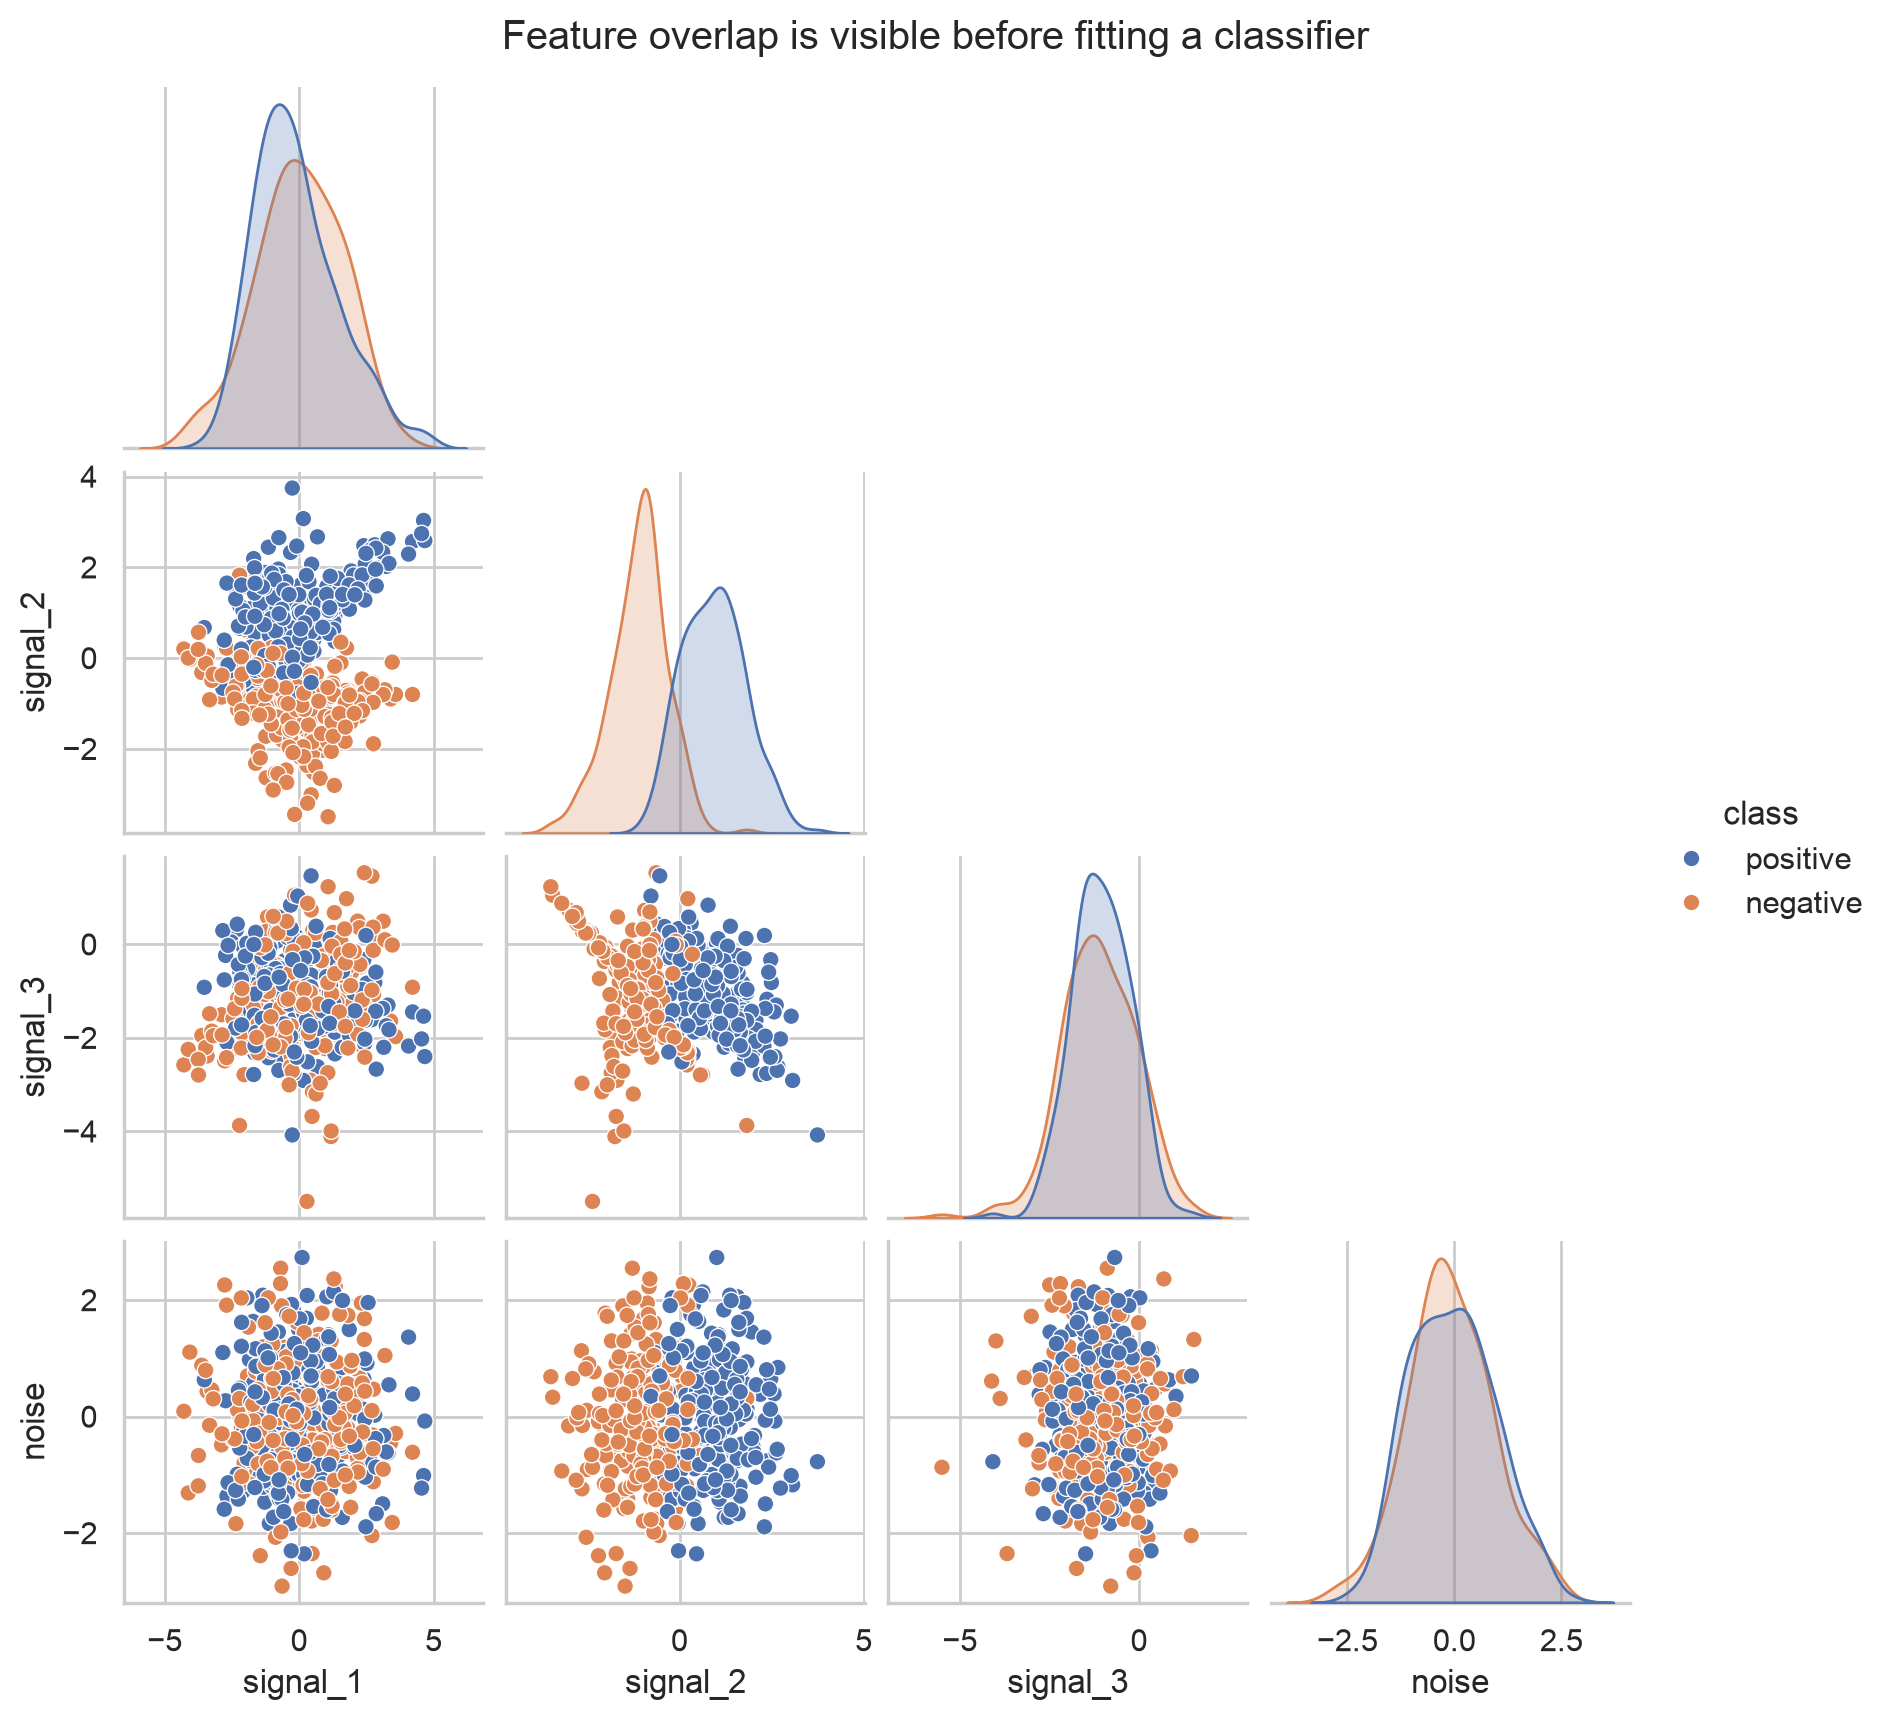

In [2]:
X, y = make_classification(
    n_samples=500, n_features=4, n_informative=3, n_redundant=0,
    class_sep=1.1, random_state=12
)
features = pd.DataFrame(X, columns=['signal_1', 'signal_2', 'signal_3', 'noise'])
features['class'] = np.where(y == 1, 'positive', 'negative')
sns.pairplot(features, vars=features.columns[:-1], hue='class', corner=True, height=2.1)
plt.suptitle('Feature overlap is visible before fitting a classifier', y=1.02)
plt.show()

## Residuals

A residual is `y - y_hat`. If a model has captured the relevant relationship, residuals should not contain an obvious trend with the prediction. The regression example fits a linear model to a curved target, so a structured residual pattern remains.


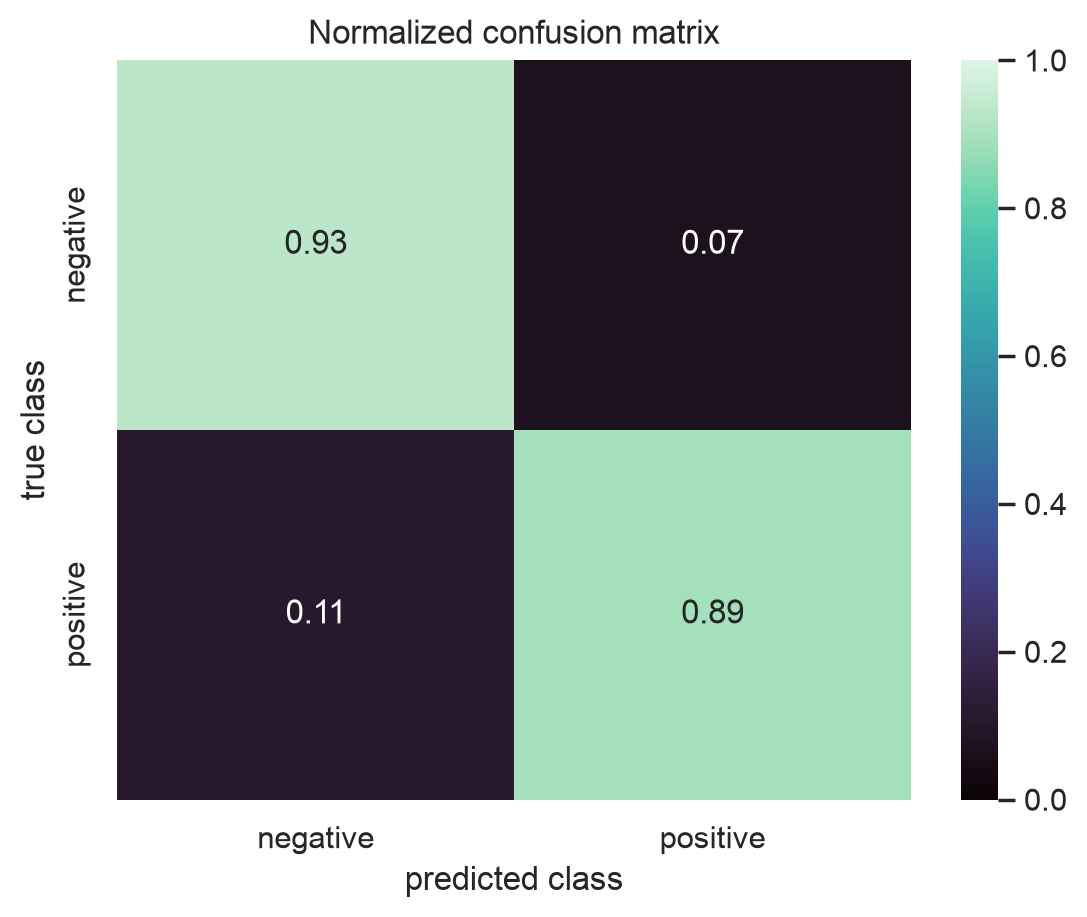

test accuracy: 0.9133333333333333


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=12
)
classifier = LogisticRegression(max_iter=1000).fit(X_train, y_train)
predictions = classifier.predict(X_test)
matrix = confusion_matrix(y_test, predictions, normalize='true')
sns.heatmap(matrix, annot=True, fmt='.2f', cmap='mako', vmin=0, vmax=1,
            xticklabels=['negative', 'positive'], yticklabels=['negative', 'positive'])
plt.xlabel('predicted class')
plt.ylabel('true class')
plt.title('Normalized confusion matrix')
plt.show()
print('test accuracy:', (predictions == y_test).mean())

## Interpreting the plots

The pair plot informs feature and preprocessing decisions. The confusion matrix informs the discussion of thresholds and error costs. The residual plot indicates that a different model family or additional features may be needed. None of the figures is a conclusion without the corresponding data split and metric.


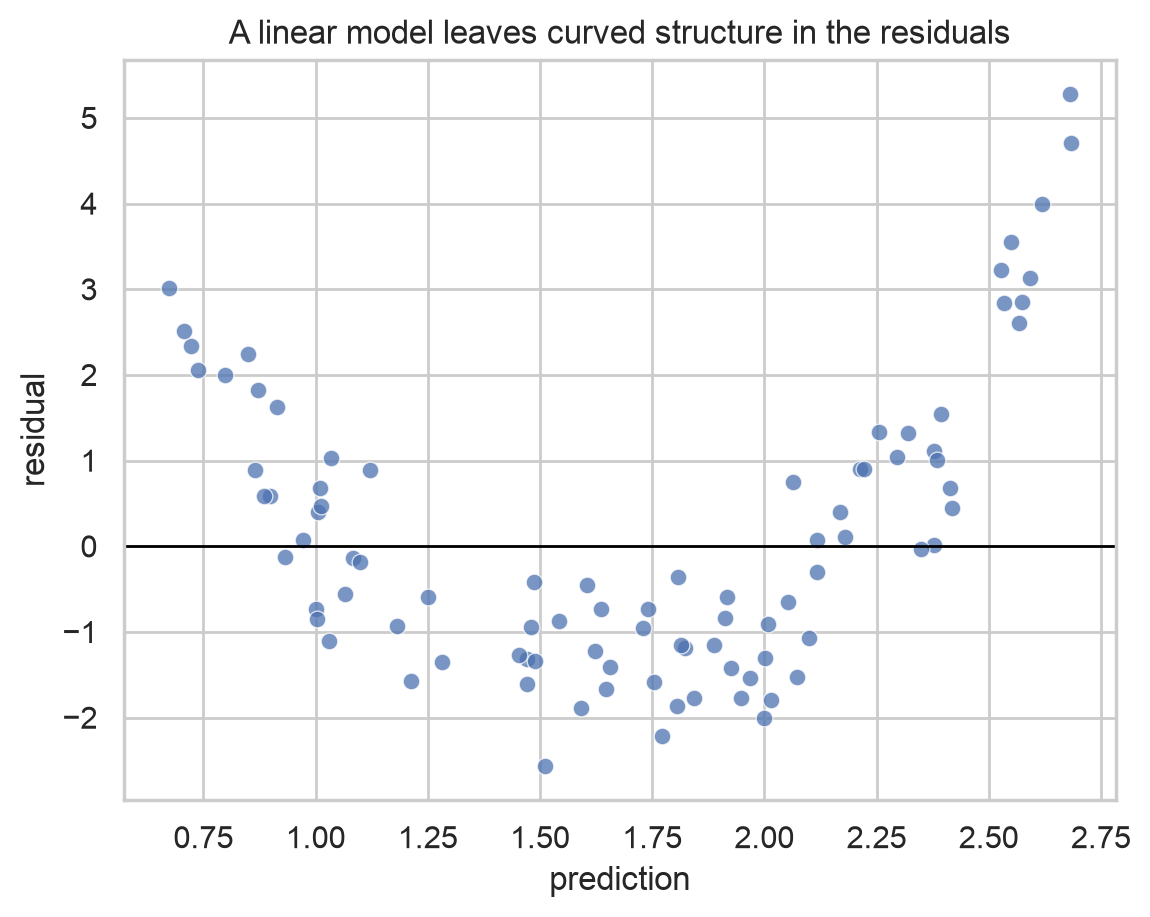

residual mean: 0.13841888026744512
residual standard deviation: 1.679018082483654


In [4]:
rng = np.random.default_rng(22)
X_reg = rng.uniform(-3, 3, size=(300, 1))
y_reg = 0.6 * X_reg[:, 0] ** 2 + 0.5 * X_reg[:, 0] + rng.normal(scale=0.7, size=len(X_reg))
X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, test_size=0.3, random_state=12)
regressor = Ridge(alpha=1.0).fit(X_train, y_train)
predictions = regressor.predict(X_test)
residuals = y_test - predictions
residual_frame = pd.DataFrame({'prediction': predictions, 'residual': residuals})
sns.scatterplot(data=residual_frame, x='prediction', y='residual', alpha=0.75)
plt.axhline(0, color='black', linewidth=1)
plt.title('A linear model leaves curved structure in the residuals')
plt.show()
print('residual mean:', residuals.mean())
print('residual standard deviation:', residuals.std())


## Limits

Visual patterns depend on axis ranges, normalization, sample size, and plotting choices. Numerical results and the evaluation protocol should remain available alongside the figure.
